# Comparing Classifiers for Building Classification Models
 In this Jupyter notebook, we will be comparing the performance of different classifiers for building classification models.

## 1. Make synthetic dataset

### 1.1. Import Library 

In [255]:
import pandas as pd 

In [256]:
from sklearn.datasets import make_classification

### 1.2. Generate the dataset 

In [257]:
X, Y = make_classification(n_samples=1000, n_classes=2, n_features=5, n_redundant=0, random_state=1)

In [258]:
X.shape

(1000, 5)

In [259]:
Y.shape

(1000,)

## 2. Data split (80--20 ratio)
### 2.1. Import library

In [260]:
from sklearn.model_selection import train_test_split

### 2.2. Data split

In [261]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

### 2.3. Let's examine the data dimension 

In [262]:
X_train.shape, X_train.shape

((800, 5), (800, 5))

In [263]:
Y_test.shape, Y_test.shape

((200,), (200,))

In [264]:
print("Full dataset:")
print(pd.Series(Y).value_counts(normalize=True))

print("\nTraining dataset:")
print(pd.Series(Y_train).value_counts(normalize=True))

print("\nTesting dataset:")
print(pd.Series(Y_test).value_counts(normalize=True))

Full dataset:
0    0.501
1    0.499
Name: proportion, dtype: float64

Training dataset:
0    0.50125
1    0.49875
Name: proportion, dtype: float64

Testing dataset:
1    0.5
0    0.5
Name: proportion, dtype: float64


# 3. Building Classification Models 
### 3.1. Import Modules

In [265]:
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier 
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import SGDClassifier

### 3.2. Defining learning classifiers

In [266]:
names = ["Nearest_Neighbors", "Linear_SVM", "Polynomial_SVM", "RBF_SVM", "Gaussian_Process",
         "Gradient_Boosting", "Decision_Tree", "Extra_Trees", "Random_Forest", "Neural_Net", "AdaBoost",
         "Naive_Bayes", "QDA", "SGD"]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025),
    SVC(kernel="poly", degree=3, C=0.025),
    SVC(kernel="rbf", C=1, gamma=2),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    GradientBoostingClassifier(n_estimators=100, learning_rate=1.0),
    DecisionTreeClassifier(max_depth=5),
    ExtraTreesClassifier(n_estimators=10, min_samples_split=2),
    RandomForestClassifier(max_depth=5, n_estimators=100),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(n_estimators=100),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
    SGDClassifier(loss="hinge", penalty="l2")]

### 3.3. Build Model, Apply Model on Test Data & Record

In [267]:
scores = []
for name, clf in zip(names, classifiers):
    clf.fit(X_train, Y_train)
    score = clf.score(X_test, Y_test)
    scores.append(score)

In [268]:
scores

[0.835,
 0.865,
 0.805,
 0.86,
 0.865,
 0.825,
 0.85,
 0.845,
 0.85,
 0.875,
 0.84,
 0.865,
 0.85,
 0.825]

# 4. Analysis of Model Performance
### 4.1. Import Library

In [269]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### 4.2. Create data frame of model performance 

In [270]:
df = pd.DataFrame()
df['Classification_model_name'] = names
df['score'] = scores
df

,Classification_model_name,score
0,Nearest_Neighbors,0.835
1,Linear_SVM,0.865
2,Polynomial_SVM,0.805
3,RBF_SVM,0.860
4,Gaussian_Process,0.865
5,Gradient_Boosting,0.825
6,Decision_Tree,0.850
7,Extra_Trees,0.845
8,Random_Forest,0.850
9,Neural_Net,0.875


### 4.3. Adding colors to the data frame

In [271]:
cm = sns.light_palette("green", as_cmap= True)
s = df.style.background_gradient(cmap=cm)
s

,Classification_model_name,score
0,Nearest_Neighbors,0.835000
1,Linear_SVM,0.865000
2,Polynomial_SVM,0.805000
3,RBF_SVM,0.860000
4,Gaussian_Process,0.865000
5,Gradient_Boosting,0.825000
6,Decision_Tree,0.850000
7,Extra_Trees,0.845000
8,Random_Forest,0.850000
9,Neural_Net,0.875000


In [272]:
df.head()
print(df.columns)
print(sns.__version__)

Index(['Classification_model_name', 'score'], dtype='object')
0.13.2


### 4.4. Bar plot of model performance 

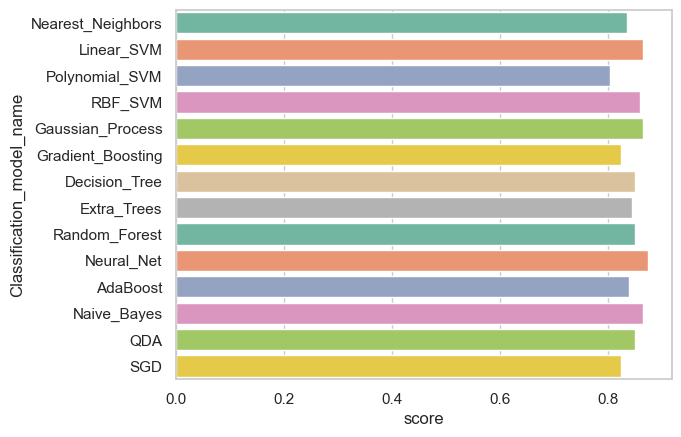

In [273]:
sns.set(style="whitegrid")

ax = sns.barplot(
    y = "Classification_model_name",
    x = "score",
    data = df,
    hue = "Classification_model_name",
    palette = "Set2",
    legend = False)
        

# Comparing test score VS training score 

In [274]:
clf.fit(X_train, Y_train)

train_score = clf.score(X_train, Y_train)
test_score = clf.score(X_test, Y_test)

print(name)
print("Train accuracy:", train_score)
print("Test accuracy:", test_score)

SGD
Train accuracy: 0.82875
Test accuracy: 0.85
